In [172]:
import sys
sys.path.append("../../src/")
import numerical_quenches as nq
from project_imports import *
import TFIM_operators_from_states as op

In [173]:
def groundstate(g,k):


    V0 = la.eigh(nq.BdG(k, g))[1][:, 1]
    u = V0[0]
    v= V0[1]

    return u,v,k


3.108372420194384


(100.0, 107.85398163397448)

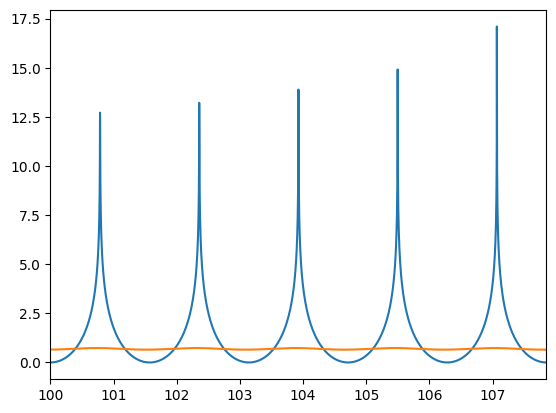

In [174]:
tau = 100
g0=5
tf = tau
args = (tau,tf)

dat=[]

kstar = np.pi - np.arcsin(
    np.clip(np.sqrt(np.log(2)/(2*np.pi*tau)), 0.0, 1.0)
)
print(kstar)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.001,tau+10*pi/4,4000)))

u0,v0,k0 = groundstate(g0,kstar)
uf,vf,kf = groundstate(0,kstar)
us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
Final_overlap = np.abs(np.conj(vf)*us+np.conj(uf)*vs)**2

LE= np.abs(np.conj(us[1])*us+np.conj(vs[1])*vs)**2
plot(t_eval,-log(LE))

LE= np.abs(np.conj(us[0])*us+np.conj(vs[0])*vs)**2
plot(t_eval,-log(LE))
#ylim(-.1,1.1)
xlim(tau,t_eval[-1])


Full State evolution

In [204]:
taus = [0.000001,5,50]

In [205]:
L=500
g0=2
overlaps=[]
overlaps1=[]
for tau in tqdm(taus):
    tf = tau
    args = (tau,tf)
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.001,tau+10*pi/4,4000)))
    states = nq.states(L,t_eval,nq.g_linear_hold,args)
    overlap = nq.overlap(states,states[0])
    overlaps.append(overlap)
    overlap = nq.overlap(states,states[1])  
    overlaps1.append(overlap)
P = array(P)

  0%|          | 0/3 [00:00<?, ?it/s]

g0=2.0


 33%|███▎      | 1/3 [00:00<00:01,  1.84it/s]

g0=2.0


 67%|██████▋   | 2/3 [00:01<00:00,  1.42it/s]

g0=2.0


100%|██████████| 3/3 [00:05<00:00,  1.71s/it]


In [206]:
overlaps=array(overlaps)
overlaps1=array(overlaps1)

In [207]:
label = ["Instant Quench"]+[rf"$\tau= {tau}$" for tau in taus[1:]]

(-0.005, 0.005)

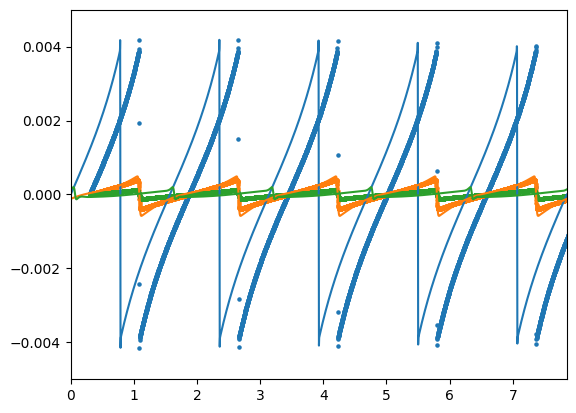

In [216]:
for o, oi in zip(overlaps,overlaps1):
    o = -log(o)/L
    oi = -log(oi)/L

    plot(t_eval-tau,np.gradient(o))
    scatter(t_eval-tau+.3,np.gradient(oi),s=5)
xlim(0,t_eval[-1]-tau)
ylim(-.005,.005)

Text(0, 0.5, '$\\lambda(t)$')

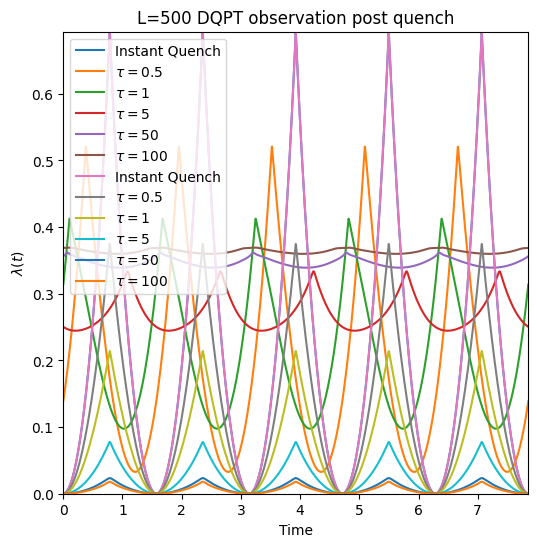

In [192]:
plt.figure(figsize=(6,6))
plot(t_eval-tau,(-log(overlaps.T)/L),label=label)
plot(t_eval-tau,(-log(overlaps1.T)/L),label=label)

ylim(0,log(2))
xlim(tau-tau,t_eval[-1]-tau)
legend(loc="upper left")
title(f"L={L} DQPT observation post quench")
xlabel("Time")
ylabel(r"$\lambda(t)$")
#savefig(f"L={L}DQPT_slow_quench.png",dpi=800)

In [136]:
taus

[1e-06, 0.5, 1, 5, 50, 100]

In [170]:
g0=5

LES=[]
for tau in taus:
    tf = tau
    args = (tau,tf)
    dat=[]

    kstar = np.pi - np.arcsin(
        np.clip(np.sqrt(np.log(2)/(2*np.pi*tau)), 0.0, 1.0)
    )
    print(kstar)
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.001,tau+10*pi/4,4000)))

    u0,v0,k0 = groundstate(g0,kstar)
    uf,vf,kf = groundstate(0,kstar)
    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    Final_overlap = np.abs(np.conj(vf)*us+np.conj(uf)*vs)**2

    LE= np.abs(np.conj(us[0])*us+np.conj(vs[0])*vs)**2
    LES.append(LE)



1.5707963267948966
2.652620610690156
2.8030198730602605
2.992502869043839
3.094603499707153
3.108372420194384


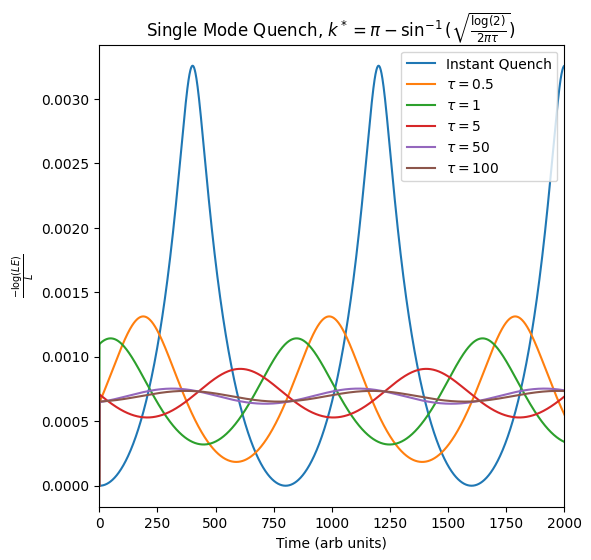

In [171]:
LES = array(LES)

plt.figure(figsize=(6,6))
ylabel(r"$\frac{-\log(LE)}{L}$")
plot(-log(LES.T)/L,label=label)
legend()
xlim(0,2000)
xlabel("Time (arb units)")
title(r"Single Mode Quench, $k^*= \pi-\sin^{-1}(\sqrt{\frac{\log(2)}{2 \pi \tau}})$ ")
savefig("predictingDQPTkstar.png",dpi=500)